# Preliminaries

In [2]:
import numpy as np
import numpy.polynomial.polynomial as poly

import matplotlib.pyplot as plt
from matplotlib import cm, gridspec
from matplotlib.ticker import FormatStrFormatter

from scipy.optimize import fsolve, root, curve_fit
from scipy.fft import fft, rfft, fftfreq, rfftfreq, ifft
from scipy import signal

import pandas as pd

plt.rcParams['text.usetex'] = True

In [3]:
#physical constants
import scipy.constants as const

#define the solar mass and megaparsec
sol = 1.989e30
Mpc = 3.086e22

print("G = {}".format(const.G))
print("c = {}".format(const.c))

G = 6.6743e-11
c = 299792458.0


# 1: Function Definitions

## Chirp Mass, Phase, and Coalescence Time

First, we define the chirp mass, phase factors, time of coalescence, and the time evolution of the separation distance and the frequency.

In [7]:
def M_chirp(m1, m2, m3):
    M = m1 + m2 + m3
    return (M**(-1/5))*(0.5 * ((m1**2)*(m2 - m3)**2 + (m2**2)*(m3 - m1)**2 + (m3**2)*(m1 - m2)**2)/(m1*m2 + m1*m3 + m2*m3))**(3/5)

def Psi_quad(m1, m2, m3):
    return np.arctan(np.sqrt(3)*m3*(m1 - m2)/(m3*(m1 + m2) - 2*m1*m2))

def Psi_omega(m1, m2, m3):
    return np.arctan((m1 - m2)*((m3 - m1)*(m3 - m2) - 3*m1*m2)/(np.sqrt(3)*m3*(m1*(m1 - m3) + m2*(m2 - m3))))

def Psi_3omega(m1, m2, m3):
    return np.arctan((m3 - m1)*(m1 - m2)*(m2 - m3)/(3*np.sqrt(3)*m1*m2*m3))

def t_c(l, m1, m2, m3):
    M = m1 + m2 + m3
    return (5/256)*(l**4)/((M_chirp(m1, m2, m3)**(5/3))*(M**(4/3)))

def a(l, m1, m2, m3, t):
    return l*(1 - t/t_c(l, m1, m2, m3))**(1/4)

def omega(l, m1, m2, m3, t):
    return (5**(3/8))/8 * (M_chirp(m1, m2, m3)**(-5/8)) * (t_c(l, m1, m2, m3) - t)**(-3/8)

def phase(l, m1, m2, m3, t):
    return -(5**(-5/8)) * (M_chirp(m1, m2, m3)**(-5/8)) * (t_c(l, m1, m2, m3) - t)**(5/8)

## Waveforms of the Binary System

Note that the definition of the chirp mass for the three-body system reduces to that of a binary system when we set one of the masses to zero. We define functions for the waveforms. For the binary system, we have the following.

In [10]:
def h_quadPlus2B(l, m1, m2, r, i_deg, t, phi = 0, radRxn = False, ampOnly = False):
    i = np.radians(i_deg)
    M = m1 + m2
    t_ret = t - r

    if radRxn == True:
        w = omega(l, m1, m2, 0, t_ret)
        PHI = phase(l, m1, m2, 0, t_ret)
    else:
        w = np.sqrt(M/(l**3))
        PHI = w*t_ret

    if ampOnly == True:
        return (2/r)*(M_chirp(m1, m2, 0)**(5/3))*(w**(2/3))*(1 + (np.cos(i))**2)
    else:
        return (2/r)*(M_chirp(m1, m2, 0)**(5/3))*(w**(2/3))*(1 + (np.cos(i))**2)*np.cos(2*PHI - np.pi + 2*phi)

def h_quadCross2B(l, m1, m2, r, i_deg, t, phi = 0, radRxn = False, ampOnly = False):
    i = np.radians(i_deg)
    M = m1 + m2
    t_ret = t - r
    
    if radRxn == True:
        w = omega(l, m1, m2, 0, t_ret)
        PHI = phase(l, m1, m2, 0, t_ret)
    else:
        w = np.sqrt(M/(l**3))
        PHI = w*t_ret

    if ampOnly == True:
        return (4/r)*(M_chirp(m1, m2, 0)**(5/3))*(w**(2/3))*np.cos(i)
    else:
        return (4/r)*(M_chirp(m1, m2, 0)**(5/3))*(w**(2/3))*np.cos(i)*np.sin(2*PHI - np.pi + 2*phi)

def h_octcqPlus2B(l, m1, m2, r, i_deg, t, phi = 0, radRxn = False, ampOnly = False):
    i = np.radians(i_deg)
    M = m1 + m2
    mu = m1*m2/M
    t_ret = t - r

    if radRxn == True:
        w = omega(l, m1, m2, 0, t_ret)
        PHI = phase(l, m1, m2, 0, t_ret)
    else:
        w = np.sqrt(M/(l**3))
        PHI = w*t_ret
    
    amp_octcqPlus = mu*(m2 - m1)*w*np.sin(i)/(4*r)
    h_octcqPlus_omega = (5 + np.cos(i)**2)*np.cos(PHI + phi)
    h_octcqPlus_3omega = -9*(1 + np.cos(i)**2)*np.cos(3*PHI + 3*phi)

    if ampOnly == True:
        return np.abs(amp_octcqPlus*np.array([5 + np.cos(i)**2, 9*(1 + np.cos(i)**2)]))
    else:
        return amp_octcqPlus*(h_octcqPlus_omega + h_octcqPlus_3omega)

def h_octcqCross2B(l, m1, m2, r, i_deg, t, phi = 0, radRxn = False, ampOnly = False):
    i = np.radians(i_deg)
    M = m1 + m2
    mu = m1*m2/M
    t_Ret = t - r

    if radRxn == True:
        w = omega(l, m1, m2, 0, t_ret)
        PHI = phase(l, m1, m2, 0, t_ret)
    else:
        w = np.sqrt(M/(l**3))
        PHI = w*t_ret

    amp_octcqCross = 3*mu*(m2 - m1)*w*np.sin(2*i)/(4*r)

    if ampOnly == True:
        return np.abs(amp_octcqCross*np.array([1, 3]))
    else:
        return amp_octcqCross*(np.sin(PHI + phi) - 3*np.sin(3*PHI + 3*phi))

def h_combinedPlus2B(t, l, m1, m2, r, i_deg, phi = 0, radRxn = False):
    return h_quadPlus2B(l, m1, m2, r, i_deg, t, phi, radRxn) + h_octcqPlus2B(l, m1, m2, r, i_deg, t, phi, radRxn)

def h_combinedCross2B(t, l, m1, m2, r, i_deg, phi = 0, radRxn = False):
    return h_quadPlus2B(l, m1, m2, r, i_deg, t, phi, radRxn) + h_octcqCross2B(l, m1, m2, r, i_deg, t, phi, radRxn)

## Waveforms of the Lagrange Three-body System

For the three-body system, we have the following.

In [13]:
def h_quadPlus3B(l, m1, m2, m3, r, i_deg, t, phi = 0, radRxn = False, ampOnly = False):
    i = np.radians(i_deg)
    M = m1 + m2 + m3
    t_ret = t - r

    if radRxn == True:
        w = omega(l, m1, m2, m3, t_ret)
        PHI = phase(l, m1, m2, m3, t_ret)
    else:
        w = np.sqrt(M/(l**3))
        PHI = w*t_ret
    
    amp_quadPlus = (-2/r)*(M**(5/6))*(M_chirp(m1, m2, m3)**(5/6))*(w**(2/3))*(1 + (np.cos(i))**2)*(np.sqrt(m1*m2 + m1*m3 + m2*m3)/M)

    if ampOnly == True:
        return np.abs(amp_quadPlus)
    else:
        return amp_quadPlus*np.cos(2*PHI - Psi_quad(m1, m2, m3) + 2*phi)

def h_quadCross3B(l, m1, m2, m3, r, i_deg, t, phi = 0, radRxn = False, ampOnly = False):
    i = np.radians(i_deg)
    M = m1 + m2 + m3
    t_ret = t - r
    
    if radRxn == True:
        w = omega(l, m1, m2, m3, t_ret)
        PHI = phase(l, m1, m2, m3, t_ret)
    else:
        w = np.sqrt(M/(l**3))
        PHI = w*t_ret
    
    amp_quadCross = (-2/r)*(M**(5/6))*(M_chirp(m1, m2, m3)**(5/6))*(w**(2/3))*np.cos(i)*(np.sqrt(m1*m2 + m1*m3 + m2*m3)/M)

    if ampOnly == True:
        return np.abs(amp_quadCross)
    else:
        return amp_quadCross*np.sin(2*PHI - Psi_quad(m1, m2, m3) + 2*phi)

def h_octcqPlus3B(l, m1, m2, m3, r, i_deg, t, phi = 0, radRxn = False, ampOnly = False):
    i = np.radians(i_deg)
    M = m1 + m2 + m3
    t_ret = t - r

    if radRxn == True:
        w = omega(l, m1, m2, m3, t_ret)
        PHI = phase(l, m1, m2, m3, t_ret)
    else:
        w = np.sqrt(M/(l**3))
        PHI = w*t_ret
    
    amp_octcqPlus = -(M**2)*w*np.sin(i)/(4*r)
    h_octcqPlus_omega = (5 + np.cos(i)**2)*np.sqrt(((np.sqrt(3)/2)*m3*(m1*(m1 - m3) + m2*(m2 - m3))/(M**3))**2 - (0.5*(m1 - m2)*((m3 - m1)*(m3 - m2) - 3*m1*m2)/(M**3))**2)
    h_octcqPlus_3omega = 9*(1 + np.cos(i)**2)*np.sqrt((3*np.sqrt(3)*m1*m2*m3/(M**3))**2 + ((m3 - m1)*(m1 - m2)*(m2 - m3)/(M**3))**2)

    if ampOnly == True:
        return np.abs(amp_octcqPlus)*np.array([(5 + np.cos(i)**2)*np.sqrt(((np.sqrt(3)/2)*m3*(m1*(m1 - m3) + m2*(m2 - m3))/(M**3))**2 - (0.5*(m1 - m2)*((m3 - m1)*(m3 - m2) - 3*m1*m2)/(M**3))**2),
                                              9*(1 + np.cos(i)**2)*np.sqrt((3*np.sqrt(3)*m1*m2*m3/(M**3))**2 + ((m3 - m1)*(m1 - m2)*(m2 - m3)/(M**3))**2)])
    else:
        return np.abs(amp_octcqPlus)*(h_octcqPlus_3omega*np.cos(3*PHI - Psi_3omega(m1, m2, m3) + 3*phi) - h_octcqPlus_omega*np.cos(PHI - Psi_omega(m1, m2, m3) + phi))

def h_octcqCross3B(l, m1, m2, m3, r, i_deg, t, phi = 0, radRxn = False, ampOnly = False):
    i = np.radians(i_deg)
    M = m1 + m2 + m3
    t_ret = t - r

    if radRxn == True:
        w = omega(l, m1, m2, m3, t_ret)
        PHI = phase(l, m1, m2, m3, t_ret)
    else:
        w = np.sqrt(M/(l**3))
        PHI = w*t_ret
    
    amp_octcqCross = -(M**2)*w*np.sin(2*i)/(4*r)
    h_octcqCross_omega = 3*( ((np.sqrt(3)/2)*m3*(m1*(m3 - m1) + m2*(m3 - m2))/(M**3))*np.sin(PHI + phi) + (0.5*(m1 - m2)*((m3 - m1)*(m3 - m2) - 3*m1*m2)/(M**3))*np.cos(PHI + phi) )
    h_octcqCross_3omega = 9*( (3*np.sqrt(3)*m1*m2*m3/(M**3))*np.sin(3*PHI + 3*phi) + ((m3 - m1)*(m1 - m2)*(m2 - m3)/(M**3))*np.cos(3*PHI + 3*phi) )

    if ampOnly == True:
        return np.abs(amp_octcqCross)*np.array([3*np.sqrt(((np.sqrt(3)/2)*m3*(m1*(m1 - m3) + m2*(m2 - m3))/(M**3))**2 + (0.5*(m1 - m2)*((m3 - m1)*(m3 - m2) - 3*m1*m2)/(M**3))**2),
                                               9*np.sqrt((3*np.sqrt(3)*m1*m2*m3/(M**3))**2 + ((m3 - m1)*(m1 - m2)*(m2 - m3)/(M**3))**2)])
    else:
        return np.abs(amp_octcqCross)*(h_octcqCross_3omega - h_octcqCross_omega)

def h_combinedPlus3B(t, l, m1, m2, m3, r, i_deg, phi = 0, radRxn = False):
    return h_quadPlus3B(l, m1, m2, m3, r, i_deg, t, phi, radRxn) + h_octcqPlus3B(l, m1, m2, m3, r, i_deg, t, phi, radRxn)

def h_combinedCross3B(t, l, m1, m2, m3, r, i_deg, phi = 0, radRxn = False):
    return h_quadCross3B(l, m1, m2, m3, r, i_deg, t, phi, radRxn) + h_octcqCross3B(l, m1, m2, m3, r, i_deg, t, phi, radRxn)

## Functions for Plotting

For convenience, we define a function that will plot the plus or cross polarization of the waveforms up until the mass octupole and current quadrupole level in the time domain and in the frequency domain.

In [16]:
def plotDegeneracy_time(t, params_2B, params_3B, phi_2B = 0, phi_3B = 0, radRxn = False, pol = "plus", filename = ""):
    #create figure object and subfigure object
    fig, (a0, a1, a2) = plt.subplots(nrows = 3, ncols = 1, sharex = True,
                                     gridspec_kw={'height_ratios': [1, 1, 2]}, figsize = (10, 7))

    if pol:
        a0.plot(t, h_quadPlus3B(*params_3B, t, phi_3B, radRxn), ls = "solid", color = "blue", label = "Lagrange triple")
        a0.plot(t, h_quadPlus2B(*params_2B, t, phi_2B, radRxn), ls = "dashed", color = "orange", label = "Binary")
        a0.set_ylabel("$h^{+}_{\mathrm{quad}}$", fontsize = "x-large")

        a1.plot(t, h_octcqPlus3B(*params_3B, t, phi_3B, radRxn), ls = "solid", color = "blue")
        a1.plot(t, h_octcqPlus2B(*params_2B, t, phi_2B, radRxn), ls = "dashed", color = "orange")
        a1.set_ylabel("$h^{+}_{\mathrm{oct+cq}}$", fontsize = "x-large")

    elif pol == "cross":
        ax0.plot(t, h_quadCross3B(*params_3B, t, phi_3B, radRxn), ls = "solid", color = "blue", label = "Lagrange triple")
        ax0.plot(t, h_quadCross2B(*params_2B, t, phi_2B, radRxn), ls = "dashed", color = "orange", label = "Binary")
        ax0.set_ylabel(r"$h^{\times}_{\mathrm{quad}}$", fontsize = "x-large")

        a1.plot(t, h_octcqCross3B(*params_3B, t, phi_3B, radRxn), ls = "solid", color = "blue")
        a1.plot(t, h_octcqCross2B(*params_2B, t, phi_2B, radRxn), ls = "dashed", color = "orange")
        a1.set_ylabel(r"$h^{\times}_{\mathrm{oct+cq}}$", fontsize = "x-large")

    a0.legend(bbox_to_anchor = (0.19, 1.6))
    
    #plot the total waveform
    a2.plot(t, h_combinedPlus3B(t, *params_3B, phi_3B, radRxn), ls = "solid", color = "blue")
    a2.plot(t, h_combinedPlus2B(t, *params_2B, phi_2B, radRxn), ls = "dashed", color = "orange")
    a2.set_xlabel("Time, $t$", fontsize = "x-large")
    a2.set_ylabel(r"$h^{+}$", fontsize = "x-large")

    if not filename:
        pass
    else:
        plt.savefig(filename, bbox_inches = "tight")
    
    plt.show()

    print("l = {}, m1 = {}, m2 = {}, m3 = {}, r = {}, i = {}".format(*params_3B))

# 2: Chirp Mass and Stability

In the case where $m_1 = m_2$, we can determine the total mass of the triple system once we know its chirp mass, which is a quantity that can be directly computed from the frequency sweep of the gravitational wave. As an example, we consider a binary system with masses $m_1 = 1.46$, $m_2 = 1.27$ and a Lagrange three-body system with parameters $m_1 = m_2 = 3.6$, $m_3 = 2.8$.

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_19889/3864668270.py:6: RuntimeWarning: invalid value encountered in power
  threeBody = plt.contour(M_chirp(3.6, 3.6, 2.8) - (M**(-1/5))*( (M - m)*((M - 3*m)**2)/(4*(M + 3*m)) )**(3/5), [0],


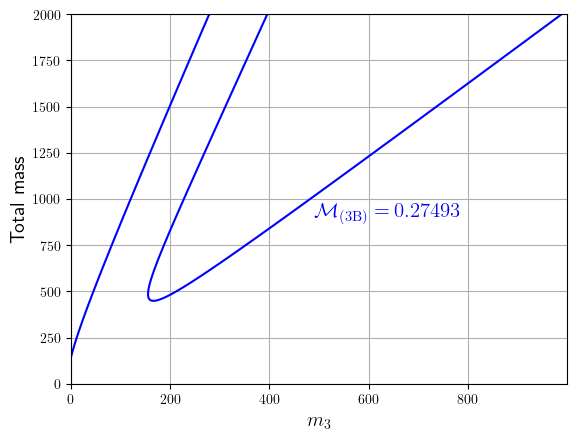

In [19]:
m_vals = np.linspace(0.01, 10, 1000)
M_vals = np.linspace(0.01, 10, 2000)
m, M = np.meshgrid(m_vals, M_vals)

#twoBody = plt.contour(M_chirp(1.46, 1.27, 0) - (M**(-1/5))*(m*(M - m))**(3/5), [0], colors = "Green", linestyles = "dashed")
threeBody = plt.contour(M_chirp(3.6, 3.6, 2.8) - (M**(-1/5))*( (M - m)*((M - 3*m)**2)/(4*(M + 3*m)) )**(3/5), [0],
           colors = "Blue")

#plt.annotate("$\mathcal{M}_{\mathrm{(2B)}} = $" + "$\: {chirp:.5f}$".format(chirp = M_chirp(1.46, 1.27, 0)), xy = (410, 1400), fontsize = 11, color = "green")
plt.annotate("$\mathcal{M}_{\mathrm{(3B)}} = $" + "$\: {chirp:.5f}$".format(chirp = M_chirp(3.6, 3.6, 2.8)), xy = (490, 900), fontsize = 15, color = "blue")

plt.ylim(0, 2000)
plt.xlabel("$m_3$", fontsize = "x-large")
plt.ylabel("Total mass", fontsize = "x-large")
plt.grid()
plt.gca().set_axisbelow(True)

plt.savefig("Chirp mass comparison 1.pdf", bbox_inches = "tight")
plt.show()

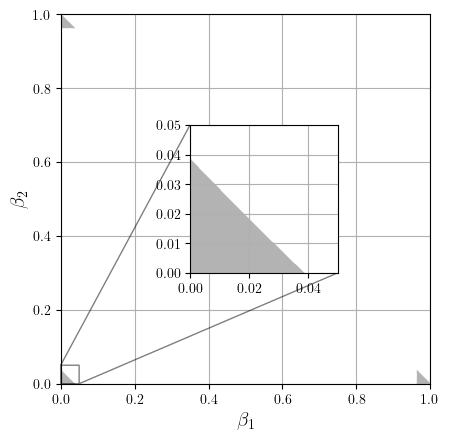

In [92]:
b1 = np.linspace(0, 1, 5000)
b2 = np.linspace(0, 1, 5000)
b1_grid, b2_grid = np.meshgrid(b1, b2)

stability = b1_grid*b2_grid + (b1_grid + b2_grid)*(1 - b1_grid - b2_grid) < 1/27
physicalMassRatios = b1_grid + b2_grid <= 1

fig, ax = plt.subplots()

#plot the stability region
ax.imshow( (stability & physicalMassRatios).astype(float), 
            extent=(b1_grid.min(), b1_grid.max(), b2_grid.min(), b2_grid.max()), 
            origin = "lower", cmap = "Greys", alpha=0.3)

ax.set_xlabel(r"$\beta_1$", fontsize = "x-large")
ax.set_ylabel(r"$\beta_2$", fontsize = "x-large")
ax.grid(True)

#inset plot
axins = ax.inset_axes([0.3, 0.3, 0.5, 0.4], xlim = (0, 0.05), ylim = (0, 0.05))
axins.imshow( (stability & physicalMassRatios).astype(float), 
            extent=(b1_grid.min(), b1_grid.max(), b2_grid.min(), b2_grid.max()), 
            origin = "lower", cmap = "Greys", alpha=0.3)
axins.grid(True)
ax.indicate_inset_zoom(axins, edgecolor = "black")

plt.savefig("LaTeX Files/Figures/System Configuration/Stability of the Lagrange Triple.pdf", bbox_inches = "tight")
plt.show()

# 3: Waveform Degeneracy up to the Quadrupole Level

Consider a binary system with parameters $m_1 = 1.46$, $m_2 = 1.27$, $l = 150$, $\iota = 30\degree$, and $r = 200,000$ and a Lagrange three-body system with parameters $m_1 = m_2$, $\iota = 30\degree$, and $r = 200,000$. By specifying the value of $m_1$ of the Lagrange three-body system, we can solve for the other parameters of the Lagrange three-body system ($m_3$ and $l$) such that the waveforms of the two systems are the same.

Without incorporating radiative losses, a binary system with parameters $m_1 = 1.46$, $m_2 = 1.27$, $l = 150$, $\iota = 30\degree$, and $r = 200,000$, and a Lagrange three-body system with the parameters obtained in solving the system of nonlinear equations above both give the same plus and cross polarization waveforms at the quadrupole level.

In [23]:
def quadDegeneracy(a, m1_2B, m2_2B, r_2B, i_2B, M_3B, beta_1):
    M_2B = m1_2B + m2_2B
    M_chirp_2B = M_chirp(m1_2B, m2_2B, 0)
    w_2B = np.sqrt(M_2B/(a**3))

    r_3B = (r_2B*(M_3B**(5/3))*beta_1*np.abs(3*beta_1 - 1))/(M_chirp_2B**(5/3))
    b = (M_3B/(w_2B**2))**(1/3)

    return b, r_3B

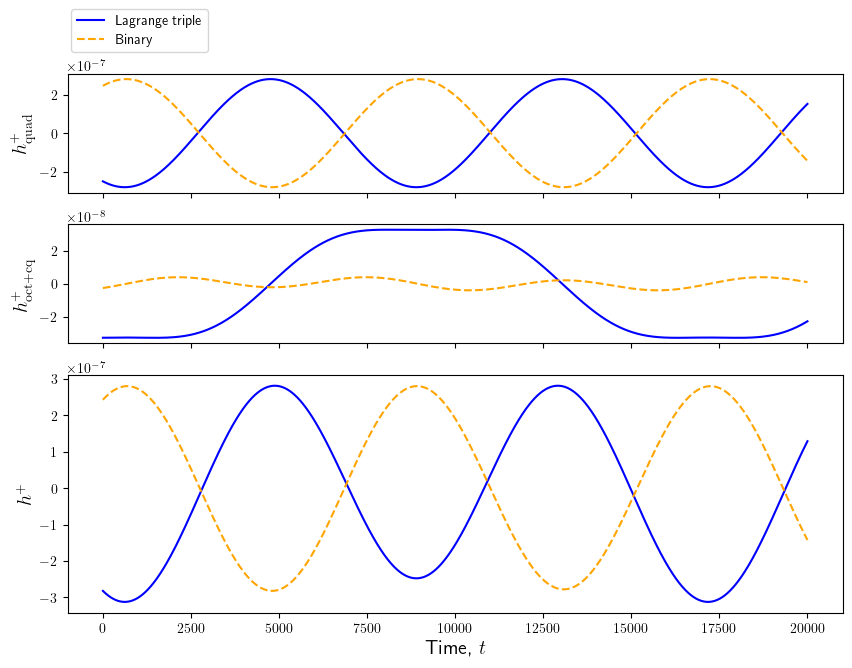

l = 1013.7003325955664, m1 = 2.25, m2 = 2.25, m3 = 145.5, r = 3974454.8960382002, i = 30
Binary coalescence = 847710.5034722226
Lagrange coalescence = 873259.6173930096


In [24]:
params_2B_1 = [500, 10, 8, 2e6, 30]

M_3B = 150
beta_1 = 0.015
beta_3 = 1 - 2*beta_1
soln_degeneracy = quadDegeneracy(*params_2B_1, M_3B, beta_1)
params_3B_1 = [soln_degeneracy[0], M_3B*beta_1, M_3B*beta_1, M_3B*beta_3, soln_degeneracy[1], 30]

t = np.linspace(0, 20000, 100000)
plotDegeneracy_time(t, params_2B_1, params_3B_1, radRxn = False)

print("Binary coalescence = {}".format(t_c(*params_2B_1[:3], 0)))
print("Lagrange coalescence = {}".format(t_c(*params_3B_1[:4])))

# 4: Waveform Degeneracy up to the 0.5PN Waveforms

## Attempt 1: Directly Solving the System of Equations

Given again the parameters of a binary system, we can solve for the parameters of the Lagrange three-body system that gives the same waveform as that of the binary system.

In [28]:
def octDegeneracy_systemOfEqns(init, a, m1_2B, m2_2B, r_2B, i_2B_deg, M_3B):
    '''init: initial guess,
    a, m1_2B, m2_2B, r_2B, i_2B_deg: parameters of the binary system,
    M_3B: total mass of the triple system
    
    Note that by specifying the total mass of the triple, we can already solve for the initial separation of each mass in the triple
    since b = (M_3B/(w_2B^2))^(1/3).
    '''
    
    #parameters of the Lagrange three-body system
    #u**2 = (r_3B), v = sin(i_3B)
    m1_3B, m3_3B, u, v = init

    #quantities that can be derived from the parameters of the binary system
    M_chirp_2B = M_chirp(m1_2B, m2_2B, 0)
    M_2B = m1_2B + m2_2B
    i_2B = np.radians(i_2B_deg)
    w_2B = np.sqrt(M_2B/(a**3))
    w_3B = w_2B
    
    eq1 = M_3B - (2*m1_3B + m3_3B)
    eq2 = 2*(M_chirp_2B**(5/3))*(w_2B**(2/3))*(1 + (np.cos(i_2B))**2)/r_2B - 2*(M_3B**(-1/3))*m1_3B*np.abs(m1_3B - m3_3B)*(w_3B**(2/3))*(2 - v**2)/(u**2)
    eq3 = (M_chirp_2B**(5/3))*(M_2B**(1/3))*w_2B*(np.abs(m2_2B - m1_2B)/M_2B)*np.sin(i_2B)*(5 + (np.cos(i_2B))**2)/(4*r_2B) - np.sqrt(3)*m1_3B*m3_3B*np.abs(m3_3B - m1_3B)*w_3B*v*(6 - v**2)/(4*(u**2)*M_3B)
    eq4 = 9*(M_chirp_2B**(5/3))*(M_2B**(1/3))*w_2B*(np.abs(m2_2B - m1_2B)/M_2B)*np.sin(i_2B)*(1 + (np.cos(i_2B))**2)/(4*r_2B) - 9*np.sqrt(27)*(m1_3B**2)*m3_3B*w_3B*v*(2 - v**2)/(4*(u**2)*M_3B)

    return [eq1, eq2, eq3, eq4]

We will use the function `scipy.optimize.root` to solve the system of equations in `octDegeneracy`. The syntax is

`root(fun, x0, args=(), method='hybr', jac=None, tol=None, callback=None, options=None)`

For convenience, we list here the available list of solvers:
1. `hybr` this is the default option and uses a modification of the Powell hybrid method as implemented in MINPACK
2. `lm` solves the system of nonlinear equations in a least squares sense using a modification of the Levenberg-Marquardt algorithm as implemented in MINPACK
3. `df-sane` is a derivative-free spectral method
4. `broyden1` and `broyden2` are Broyden’s good method and bad method, respectively
5. `anderson` uses (extended) Anderson mixing
6. `Krylov` uses Krylov approximation for inverse Jacobian; this is suitable for large-scale problems
7. `diagbroyden` uses diagonal Broyden Jacobian approximation
8. `linearmixing` uses a scalar Jacobian approximation
9. `excitingmixing` uses a tuned diagonal Jacobian approximation

Consider a binary system with parameters $m_1 = 10$, $m_2 = 100$, $a = 300$, $r = 2 \times 10^5$, $\iota = 15\degree$. If we impose that the triple system has a total mass of $M_{(\mathrm{3B})} = 25$, we can solve for the remaining parameters of the triple system so that its GW is the same as that of the binary system.

First, we will try to direclty solve the system of equations in `octDegeneracy_reduced` using available solvers in 

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_3114/1036456411.py:3: RuntimeWarning: invalid value encountered in scalar power
  return (M**(-1/5))*(0.5 * ((m1**2)*(m2 - m3)**2 + (m2**2)*(m3 - m1)**2 + (m3**2)*(m1 - m2)**2)/(m1*m2 + m1*m3 + m2*m3))**(3/5)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_3114/1263579177.py:13: RuntimeWarning: invalid value encountered in sqrt
  amp_quadPlus = (-2/r)*(M**(5/6))*(M_chirp(m1, m2, m3)**(5/6))*(w**(2/3))*(1 + (np.cos(i))**2)*(np.sqrt(m1*m2 + m1*m3 + m2*m3)/M)


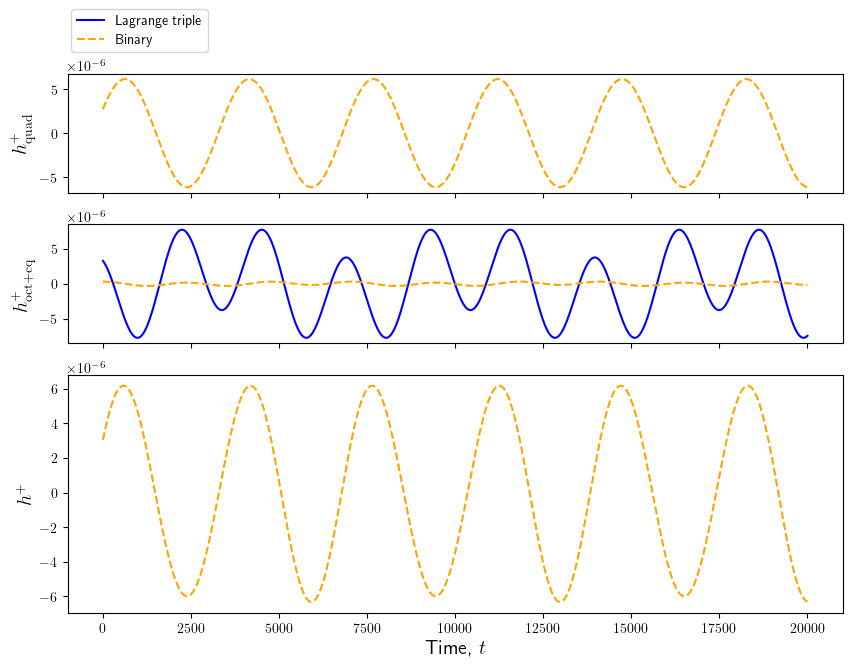

l = 184.77363318508765, m1 = -7.699999999999999, m2 = -7.699999999999999, m3 = 20.4, r = 141000.0, i = 10.375


In [32]:
params_3B_1 = []
M_3B = 5

params_2B_1 = [300, 13.7, 7.7, 2e5, 30]
M_2B = params_2B_1[1] + params_2B_1[2]
w_2B = np.sqrt(M_2B/(params_2B_1[0]**3))

soln_Degeneracy = root(octDegeneracy_systemOfEqns, [4.8, 20.4, 141000**2, np.sin(np.radians(10.375))], args = (*params_2B_1, M_3B), method = "lm", tol = 1e-20)

params_3B_1.append([(M_3B/(w_2B**2))**(1/3), soln_Degeneracy.x[0], soln_Degeneracy.x[0], soln_Degeneracy.x[1], np.sqrt(soln_Degeneracy.x[2]), np.degrees(np.arcsin(soln_Degeneracy.x[3]))])

t = np.linspace(0, 20000, 100000)
plotDegeneracy_time(t, params_2B_1, params_3B_1[0], False)

## Attempt 2: Fitting the Signal of the Triple to the Waveform of the Binary

Unfortunately, to solve the system of equations in `octDegeneracy_reduced`, the initial guess must lie close to the solution. Even by imposing a restriction on the total mass of the triple system, we do not have enough information to determine the appropriate initial guess for the solution. As an alternative, we can try generating the waveform of the binary system using `h_combinedPlus2B` and then fitting the parameters of the triple system to the waveform of the binary system using `scipy.optimize.curve_fit`.

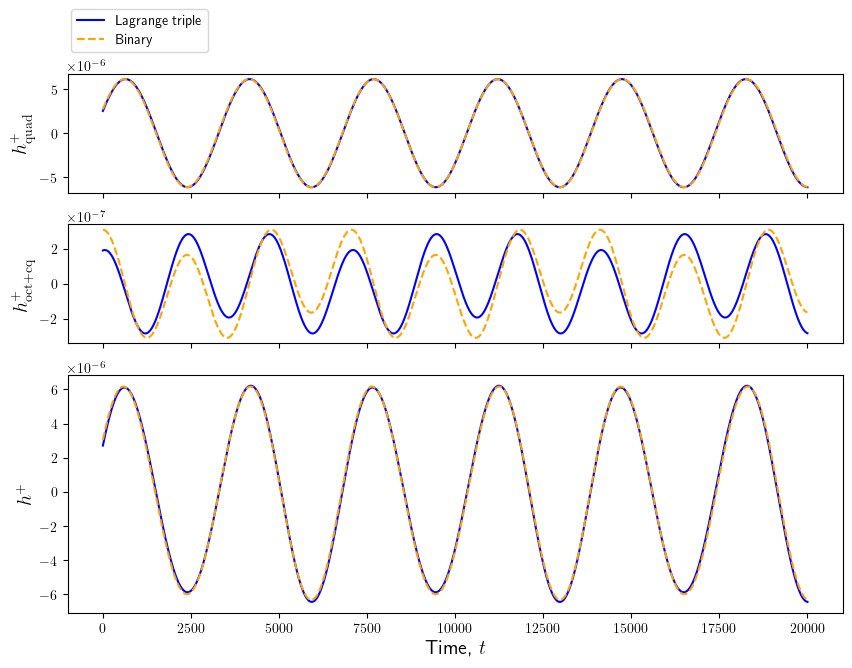

l = 316.2699492040505, m1 = 1.674355060334857e-05, m2 = 3.14818769584593, m3 = 22.026539040829412, r = 140338.13377492988, i = 9.920751929227798


In [35]:
t = np.linspace(0, 20000, 100000)
params_2B_1 = [300, 13.7, 7.7, 2e5, 30]

bounds = ([0, 0, 0, 0, 0, 5], [np.inf, 10, 10, 25, np.inf, 90])
fit_params_3B, fit_cov_3B = curve_fit(h_combinedPlus3B, t, h_combinedPlus2B(t, *params_2B_1), [335.7, 4.8, 4.8, 20.4, 141000, 10.375], bounds = bounds)

plotDegeneracy_time(t, params_2B_1, fit_params_3B, False)

We see that it is easier to find the parameters of the triple that matches that of the binary using `curve_fit`. As we increase the initial guess for the masses, we also need to increase our guess for the initial separation distance $b$ of the masses.

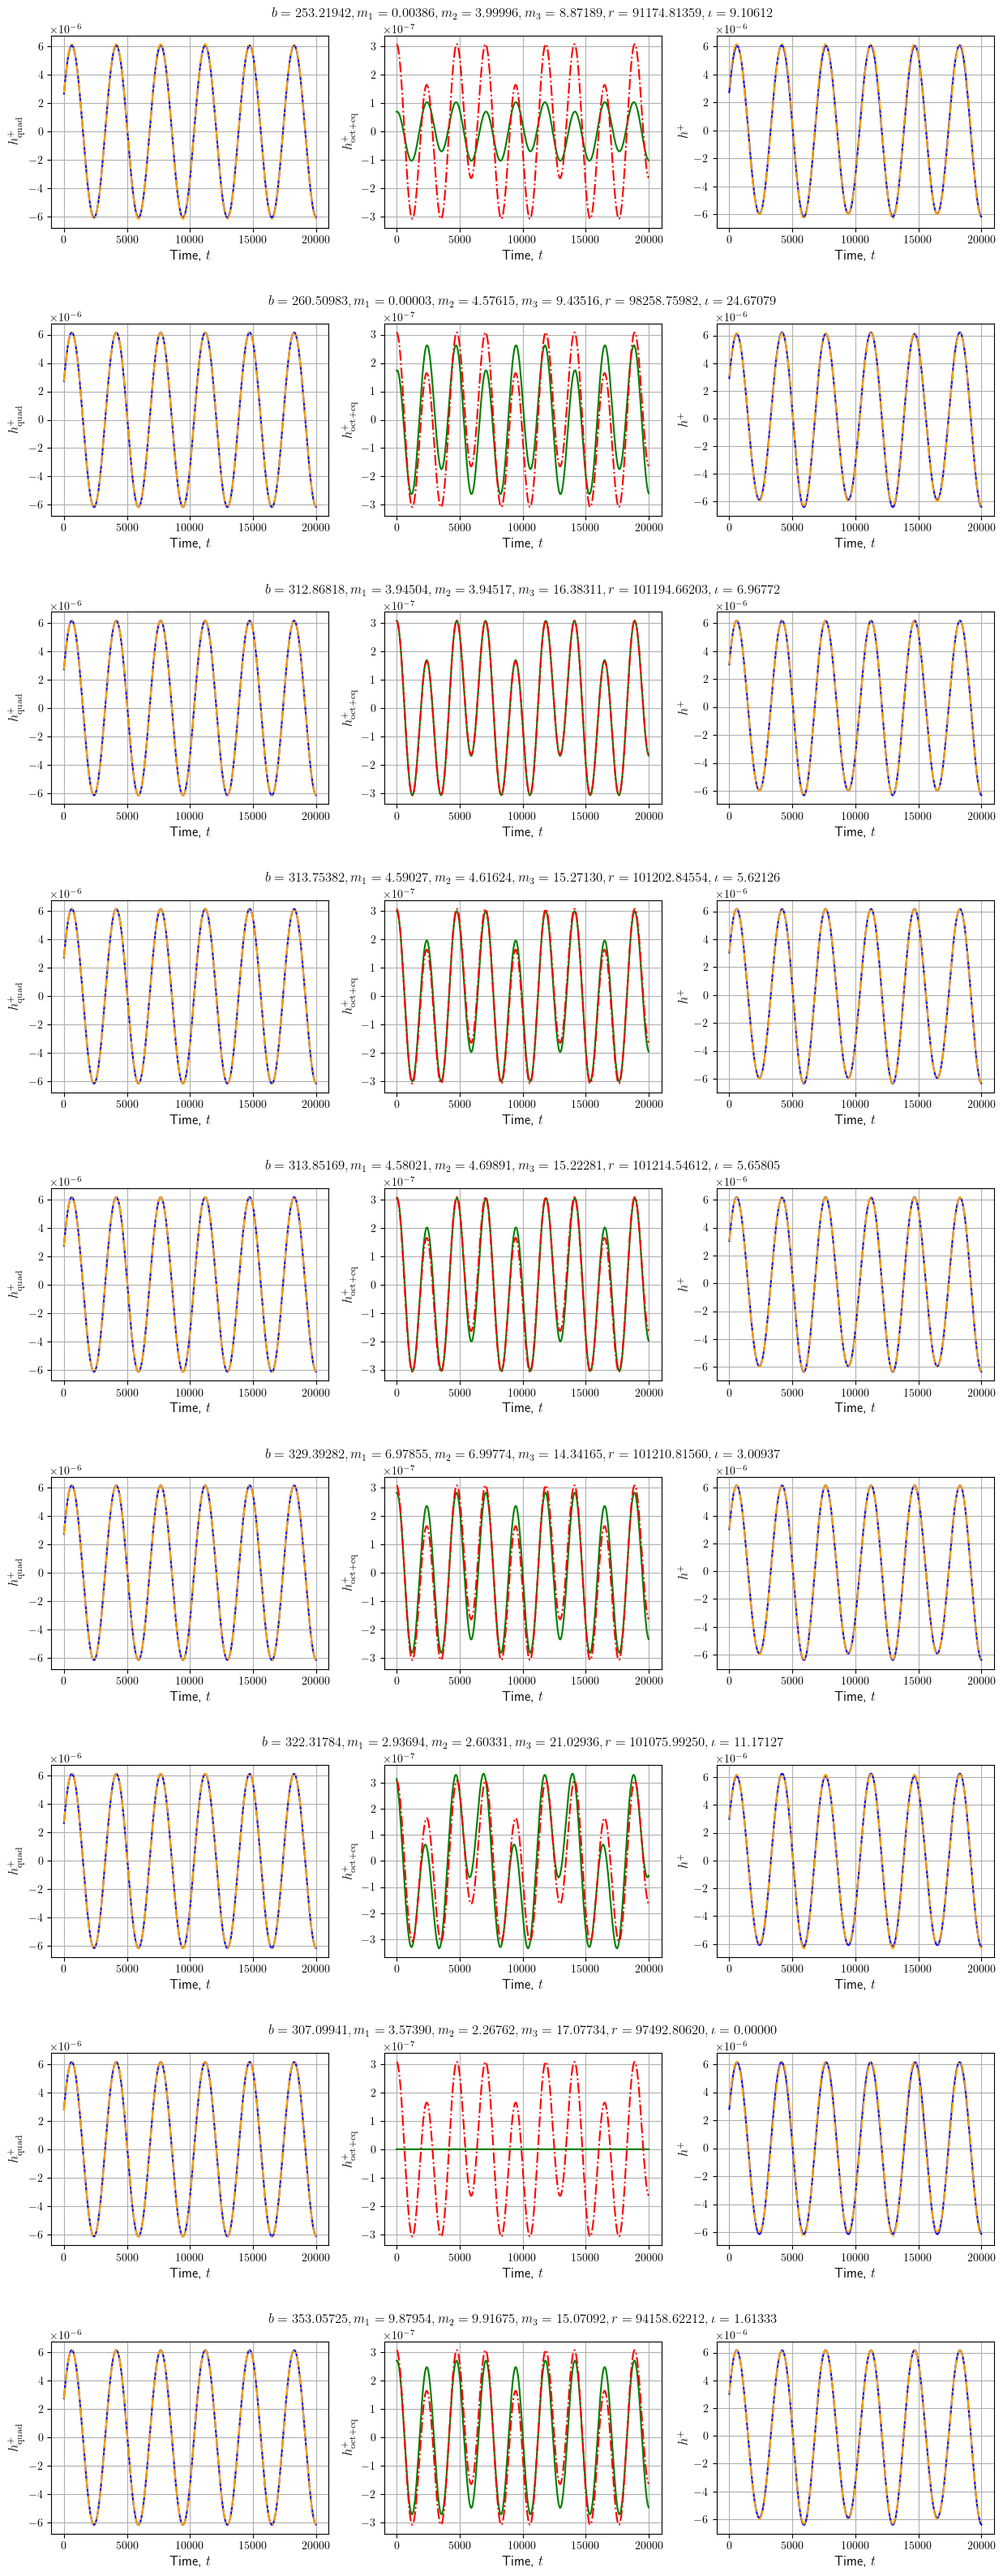

In [37]:
fig, ax = plt.subplots(nrows = 9, ncols = 3, figsize = (15, 40))

t = np.linspace(0, 20000, 100000)
params_2B_1 = [300, 13.7, 7.7, 2e5, 30]

degenerate_params = []

for i in range(0, 9):
    bounds = ([0, 0, 0, 0, 0, 0], [np.inf, i + 4, i + 4, 5*(i + 4), np.inf, 90])
    fit_params_3B, fit_cov_3B = curve_fit(h_combinedPlus3B, t, h_combinedPlus2B(t, *params_2B_1), [250 + 20*i, i + 2, i + 2, 3*(i + 2), 100000, 15], bounds = bounds)
    degenerate_params.append(fit_params_3B)
    
    ax[i][0].plot(t, h_quadPlus3B(*fit_params_3B, t), color = "blue", ls = "solid")
    ax[i][0].plot(t, h_quadPlus2B(*params_2B_1, t), color = "orange", ls = "-.")
    ax[i][0].set_xlabel("Time, $t$", fontsize = "large")
    ax[i][0].set_ylabel("$h^{+}_{\mathrm{quad}}$", fontsize = "large")
    ax[i][0].grid()
    ax[i][0].set_axisbelow(True)

    ax[i][1].plot(t, h_octcqPlus3B(*fit_params_3B, t), color = "green", ls = "solid")
    ax[i][1].plot(t, h_octcqPlus2B(*params_2B_1, t), color = "red", ls = "-.")
    ax[i][1].set_xlabel("Time, $t$", fontsize = "large")
    ax[i][1].set_ylabel("$h^{+}_{\mathrm{oct + cq}}$", fontsize = "large")
    ax[i][1].grid()
    ax[i][1].set_axisbelow(True)

    ax[i][2].plot(t, h_combinedPlus3B(t, *fit_params_3B), color = "blue", ls = "solid")
    ax[i][2].plot(t, h_combinedPlus2B(t, *params_2B_1), color = "orange", ls = "-.")
    ax[i][2].set_xlabel("Time, $t$", fontsize = "large")
    ax[i][2].set_ylabel("$h^{+}$", fontsize = "large")
    ax[i][2].grid()
    ax[i][2].set_axisbelow(True)

    ax[i][1].set_title("$b = {:.5f}, m_1 = {:.5f}, m_2 = {:.5f}, m_3 = {:.5f}, r = {:.5f}, \iota = {:.5f}$".format(*fit_params_3B))

plt.subplots_adjust(hspace = 0.5)
plt.show()

## Attempt 3: Analytical Solution

We can solve for the $\iota_{\mathrm{(3B)}}$ as a function of the mass ratios $\beta_1$ and $\beta_2$ using the equations describing the degeneracy at the mass octupole level.

In [40]:
params_2B_1 = [300, 13.7, 7.7, 2e5, 30]

In [41]:
def F(b1, b2):
    num = 3*((b1 + b2 - 1)**2)*((2*b1**2 + (b1 + b2)*(2*b2 - 1))**2) + (b1 - 3*b1**2 + 2*b1**3 + b2*(b2*(3 - 2*b2) - 1))**2
    denom = 27*(b1**2)*(b2**2)*((b1 + b2 - 1)**2) + ((b1 - b2)**2)*((2*b1 + b2 - 1)**2)*((b1 + 2*b2 - 1)**2)

    return np.sqrt(num/denom)

def iota(b1, b2, ratio_w_3w):
    return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_3114/2151087883.py:5: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_3114/2151087883.py:8: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_3114/2151087883.py:8: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


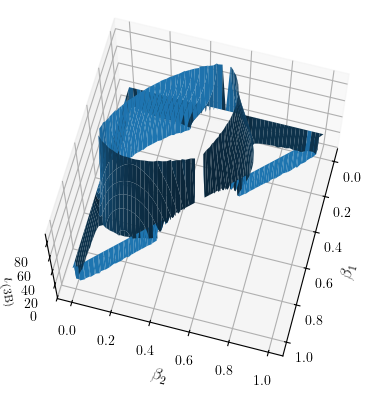

In [42]:
fig = plt.figure()
ax = fig.add_subplot(projection = "3d")

ratio_w_3w = h_octcqPlus2B(*params_2B_1, t, ampOnly = True)[0]/h_octcqPlus2B(*params_2B_1, t, ampOnly = True)[1]
b1 = np.linspace(0, 1, 10000)
b2 = np.linspace(0, 1, 10000)
b1_grid, b2_grid = np.meshgrid(b1, b2)
i = iota(b1_grid, b2_grid, ratio_w_3w)
i[b1_grid + b2_grid >= 1] = np.nan

surf = ax.plot_surface(b1_grid, b2_grid, i, linewidth = 0.2, antialiased = True)

ax.set_xlabel(r"$\beta_1$", fontsize = "large")
ax.set_ylabel(r"$\beta_2$", fontsize = "large")
ax.set_zlabel(r"$\iota_{\mathrm{(3B)}}$", fontsize = "large", rotation = 45)

ax.zaxis.labelpad = -1

ax.grid()
ax.view_init(67, 15)
plt.show()

Any point on the surface $\iota_{\mathrm{(3B)}} = \iota_{\mathrm{(3B)}}(\beta_1, \beta_2)$ represents the parameters of the triple system such that the ratio of the amplitudes of the 0.5-PN waveform at $\omega$ and $3\omega$ is equal to the ratio of the amplitudes of the 0.5-PN waveform of the binary system at $\omega$ and $3\omega$.

In [44]:
np.min(np.roots([-3, 2, -1/27]))

np.float64(0.019063652805978878)

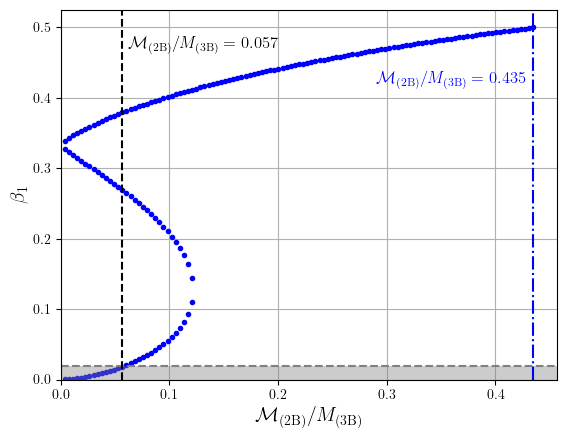

In [141]:
a1 = np.linspace(0, 0.45, 120)

#plt.figure(figsize = (10,5))

checkLastStableValue = 0
checkAllowedValues = []

for val in a1:
    temp = poly.polyroots([-8*(val**5), 36*(val**5), -54*(val**5), 1 + 27*val**5, -18, 135, -540, 1215, -1458, 729])
    temp = temp[np.isclose(temp.imag, 0)]
    temp = temp[temp > 0]

    for root in temp:
        if root <= 0.5:
            plt.scatter(val, root, color = "blue", marker = ".")

            if val not in checkAllowedValues:
                checkAllowedValues.append(val)
    
    if len(temp) > 0 and np.min(temp) < np.min(np.roots([-3, 2, -1/27])):
        checkLastStableValue = val

plt.xlabel(r"$\mathcal{M}_{\mathrm{(2B)}}/M_{\mathrm{(3B)}}$", fontsize = "x-large")
plt.ylabel(r"$\beta_1$", fontsize = "x-large")
plt.grid()
plt.gca().set_axisbelow(True)
plt.ylim(0)
plt.xlim(0)

#plot stability regions
plt.axhspan(0, np.min(np.roots([-3, 2, -1/27])), facecolor = "gray", alpha = 0.4)
plt.axhline(np.min(np.roots([-3, 2, -1/27])), color = "gray", ls = "--")
plt.axvline(checkAllowedValues[-1], color = "blue", ls = "-.")
plt.annotate(r"$\mathcal{{M}}_{{\mathrm{{(2B)}}}}/M_{{\mathrm{{(3B)}}}} = {:.3f}$".format(checkAllowedValues[-1]),
             xy = (checkAllowedValues[-1] - 0.145, 0.42), fontsize = 12, color = "blue")
plt.axvline(checkLastStableValue, color = "black", ls = "--")
plt.annotate(r"$\mathcal{{M}}_{{\mathrm{{(2B)}}}}/M_{{\mathrm{{(3B)}}}} = {:.3f}$".format(checkLastStableValue),
             xy = (checkLastStableValue + 0.005, 0.47), fontsize = 12)

plt.savefig("LaTeX Files/Figures/Chirp Mass/Roots of G(beta_1).pdf", bbox_inches = "tight")
plt.show()

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_3114/2151087883.py:5: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_3114/2151087883.py:8: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_3114/2151087883.py:8: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


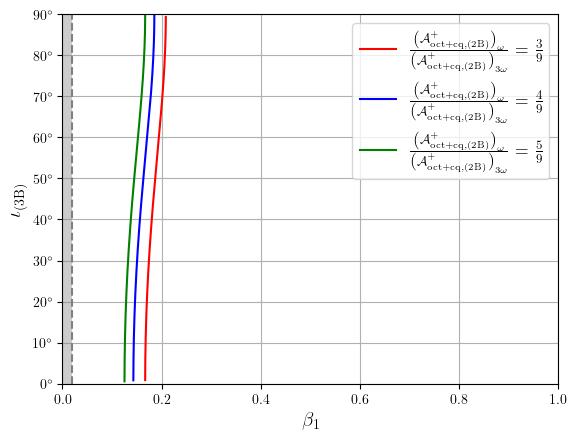

In [46]:
#generate the data
ratios = [3/9, 4/9, 5/9]
b1 = np.linspace(0, 0.5, 50000)

#colors and line styles for plotting
colors = ["Red", "Blue", "Green"]
ratio_labels = [r"$\ \frac{3}{9}$", r"$\ \frac{4}{9}$", r"$\ \frac{5}{9}$"]

for i in range(len(ratios)):
    plt.plot(b1, iota(b1, b1, ratios[i]), color = colors[i],
             label = r"$\frac{\left( \mathcal{A}_{\mathrm{oct+cq,(2B)}}^{+} \right)_{\omega}}{\left( \mathcal{A}_{\mathrm{oct+cq,(2B)}}^{+} \right)_{3\omega}} = $" + ratio_labels[i])

#plot the stability region
plt.axvspan(0, np.min(np.roots([-3, 2, -1/27])), facecolor = "gray", alpha = 0.4)
plt.axvline(np.min(np.roots([-3, 2, -1/27])), color = "gray", ls = "--")

plt.legend(fontsize = 13)
plt.xlabel(r"$\beta_1$", fontsize = "x-large")
plt.ylabel(r"$\iota_{\mathrm{(3B)}}$", fontsize = "x-large")
plt.grid()
plt.gca().set_axisbelow(True)
plt.gca().yaxis.set_major_formatter(FormatStrFormatter("$%d^{\circ}$"))
plt.ylim(0, 90)
plt.xlim(0, 1)

plt.savefig("LaTeX Files/Figures/0.5PN Degeneracy/Iota vs Masses (b1 = b2).pdf", bbox_inches = "tight")
plt.show()

From this, we can get $\beta_3$ and $b$. However, although the ratios of the amplitudes of the 0.5-PN waveform of both systems may be equal, we still need to find the point (if it exists) $\beta_1 = \beta_2$ where amplitudes of the 0.5-PM waveform of both systems are exactly identical. As a brute force method, we can iteratively look for the values of $\beta_1 = \beta_2$ in the range $\beta_1 + \beta_2 < 1$. Then, to have a complete match at both the quadrupole and octupole level, we can determine $r_{\mathrm{(3B)}}$ using the equation that dictates the degeneracy at the quadrupole level.

In [48]:
t = np.linspace(0, 20000, 100000)

def find_M_3B(a, m1_2B, m2_2B, r_2B, i_2B_deg, b1):
    #quantities obtainable from the known binary system
    amp_quadPlus_2B = h_quadPlus2B(a, m1_2B, m2_2B, r_2B, i_2B_deg, t, ampOnly = True)
    amp_octcqPlus_2B_w = h_octcqPlus2B(a, m1_2B, m2_2B, r_2B, i_2B_deg, t, ampOnly = True)[0]
    amp_octcqPlus_2B_3w = h_octcqPlus2B(a, m1_2B, m2_2B, r_2B, i_2B_deg, t, ampOnly = True)[1]
    w_2B = np.sqrt((m1_2B + m2_2B)/(a**3))

    #parameters obtainable from the equivalent Lagrange triple
    b3 = 1 - 2*b1
    i_3B = np.radians(iota(b1, b1, amp_octcqPlus_2B_w/amp_octcqPlus_2B_3w))

    term1 = (np.sqrt(3)*b3/8)*(amp_quadPlus_2B/amp_octcqPlus_2B_w)*(np.sin(i_3B)*(5 + np.cos(i_3B)**2)/(1 + np.cos(i_3B)**2))*(w_2B**(1/3))
    term2 = (9*np.sqrt(27)/8)*(b1*b3/np.abs(b1 - b3))*(amp_quadPlus_2B/amp_octcqPlus_2B_3w)*np.sin(i_3B)*(w_2B**(1/3))

    return (1/2)*(term1**(-3)) + (1/2)*(term2**(-3))

def find_r(a, m1_2B, m2_2B, r_2B, i_2B_deg, b1):
    #quantities obtainable from the known binary system
    amp_quadPlus_2B = h_quadPlus2B(a, m1_2B, m2_2B, r_2B, i_2B_deg, t, ampOnly = True)
    amp_octcqPlus_2B_w = h_octcqPlus2B(a, m1_2B, m2_2B, r_2B, i_2B_deg, t, ampOnly = True)[0]
    amp_octcqPlus_2B_3w = h_octcqPlus2B(a, m1_2B, m2_2B, r_2B, i_2B_deg, t, ampOnly = True)[1]
    w_2B = np.sqrt((m1_2B + m2_2B)/(a**3))

    #parameters obtainable from the equivalent Lagrange triple
    i_3B = np.radians(iota(b1, b1, amp_octcqPlus_2B_w/amp_octcqPlus_2B_3w))
    b3 = 1 - 2*b1
    M_3B = find_M_3B(a, m1_2B, m2_2B, r_2B, i_2B_deg, b1)

    term1 = 2*(M_3B**(5/3))*(w_2B**(2/3))*b1*np.abs(b1 - b3)*(1 + np.cos(i_3B)**2)
    term2 = (np.sqrt(3)/4)*(M_3B**2)*w_2B*b1*b3*np.abs(b1 - b3)*np.sin(i_3B)*(5 + np.cos(i_3B)**2)
    term3 = (9*np.sqrt(27)/4)*(M_3B**2)*w_2B*(b1**2)*b3*np.sin(i_3B)*(1 + np.cos(i_3B)**2)
    
    return (term1 + term2 + term3)/(amp_quadPlus_2B + amp_octcqPlus_2B_w + amp_octcqPlus_2B_3w)

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_3114/2151087883.py:5: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_3114/2151087883.py:8: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_3114/2151087883.py:8: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


[0.15909232 0.15909432 0.15909632 ... 0.2011444  0.2011464  0.2011484 ]


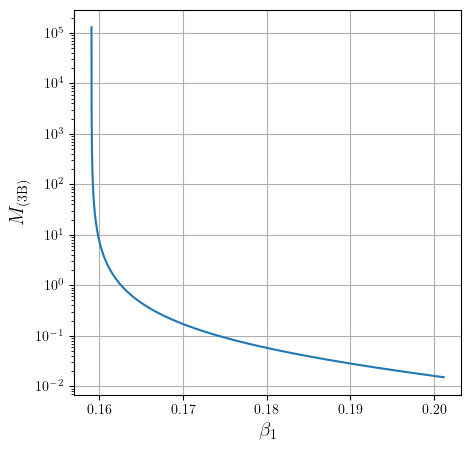

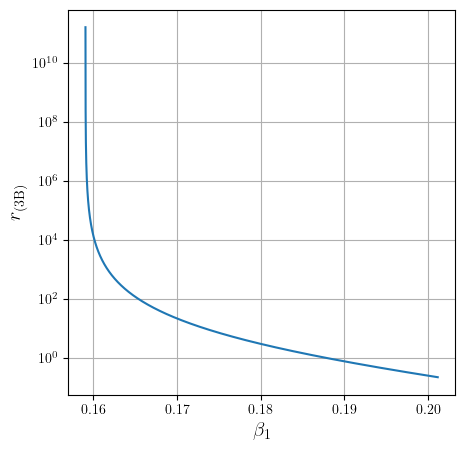

In [111]:
#generate the data
ratio_w_3w = h_octcqPlus2B(*params_2B_1, t, ampOnly = True)[0]/h_octcqPlus2B(*params_2B_1, t, ampOnly = True)[1]

b1 = np.linspace(0, 1, 500000)
b2 = np.linspace(0, 1, 500000)
i_3B = iota(b1, b2, ratio_w_3w)
i_3B[b1 > 0.5] = np.nan

#plot M_3B and r_3B for the given binary system
#find the values of b1 where i_3B is defined (i.e., the values of b1 that are part of the domain of i_3B)
b1_filtered = b1[np.where(~np.isnan(i_3B))]
print(b1_filtered)

start_index = 0

fig = plt.figure(figsize = (5, 5))
plt.plot(b1_filtered[start_index:], find_M_3B(*params_2B_1, b1_filtered[start_index:]))
plt.xlabel(r"$\beta_1$", fontsize = "x-large")
plt.ylabel(r"$M_{\mathrm{(3B)}}$", fontsize = "x-large")
plt.grid()
plt.gca().set_axisbelow(True)
plt.yscale("log")

#plt.savefig("M_3B vs beta_1.pdf", bbox_inches = "tight")
plt.show()

fig = plt.figure(figsize = (5, 5))
plt.plot(b1_filtered[start_index:], find_r(*params_2B_1, b1_filtered[start_index:]))
plt.xlabel(r"$\beta_1$", fontsize = "x-large")
plt.ylabel(r"$r_{\mathrm{(3B)}}$", fontsize = "x-large")
plt.grid()
plt.gca().set_axisbelow(True)
plt.yscale("log")

#plt.savefig("r_3B vs beta_1.pdf", bbox_inches = "tight")
plt.show()

In [50]:
def findOctDegeneracy(t, params_2B, beta_1, filename = "", radRxn = False):
    #generate the data
    ratio_w_3w = h_octcqPlus2B(*params_2B, t, ampOnly = True)[0]/h_octcqPlus2B(*params_2B, t, ampOnly = True)[1]
    
    b1 = np.linspace(0, 1, 500000)
    b2 = np.linspace(0, 1, 500000)
    i_3B = iota(b1, b2, ratio_w_3w)
    i_3B[b1 > 0.5] = np.nan
    
    #plot M_3B and r_3B for the given binary system
    #find the values of b1 where i_3B is defined (i.e., the values of b1 that are part of the domain of i_3B)
    b1_filtered = b1[np.where(~np.isnan(i_3B))]

    print("Min beta_1 for true degeneracy = {}".format(b1_filtered[0]))
    print("Max beta_1 for true degeneracy = {}".format(b1_filtered[-1]))

    if b1_filtered[0] < beta_1 < b1_filtered[-1]:
        #calculate the parameters obtainable from the given binary system      
        amp_octcqPlus_2B_w = h_octcqPlus2B(*params_2B, t, ampOnly = True)[0]
        amp_octcqPlus_2B_3w = h_octcqPlus2B(*params_2B, t, ampOnly = True)[1]
        ratio_w_3w = amp_octcqPlus_2B_w/amp_octcqPlus_2B_3w
        w_2B = np.sqrt((params_2B[1] + params_2B[2])/(params_2B[0]**3))

        #find the parameters of the equivalent Lagrange triple
        M_3B = find_M_3B(*params_2B, beta_1)
        r_3B = find_r(*params_2B, beta_1)
        b = (M_3B/(w_2B**2))**(1/3)
        m1_3B = M_3B*beta_1
        m3_3B = M_3B - 2*m1_3B
        i_3B_deg = iota(beta_1, beta_1, ratio_w_3w)

        #compile the parameters of the triple into one list
        params_3B = [b, m1_3B, m1_3B, m3_3B, r_3B, i_3B_deg]

        if radRxn == False:
            plotDegeneracy_time(t, params_2B, params_3B, phi_2B = w_2B*params_2B[3], phi_3B = w_2B*r_3B, filename = filename)
        else:
            phi_3B = phase(params_3B[0], params_3B[1], params_3B[2], params_3B[3], t)[0] - phase(params_2B[0], params_2B[1], params_2B[2], 0, t)[0]
            plotDegeneracy_time(t, params_2B, params_3B, phi_2B = 0, phi_3B = phi_3B, radRxn = radRxn, filename = filename)
    else:
        print("Mass ratio not in the region for true degeneracy.")

/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_3114/2151087883.py:5: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_3114/2151087883.py:8: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_3114/2151087883.py:8: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


Min beta_1 for true degeneracy = 0.15909231818463634
Max beta_1 for true degeneracy = 0.20114840229680458


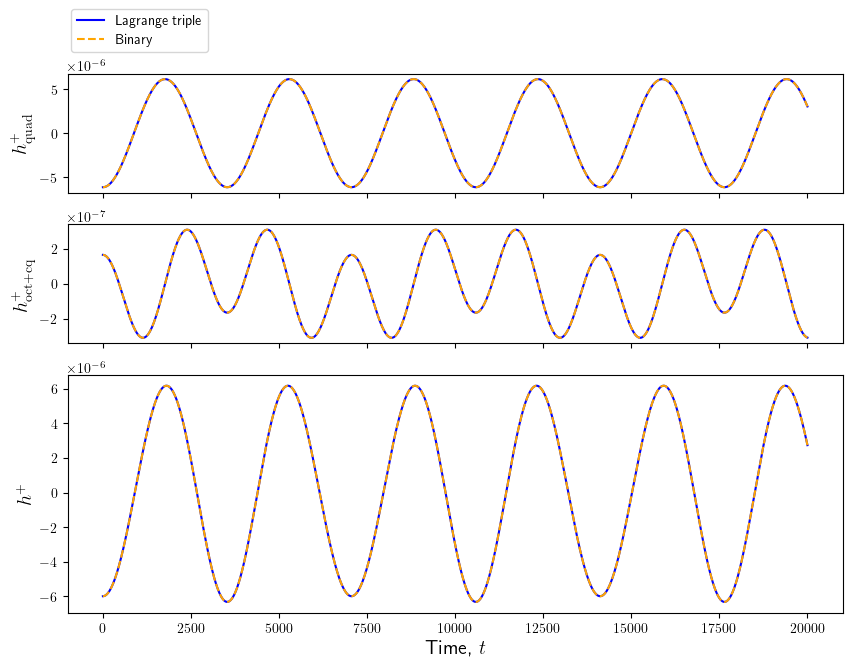

l = 320.6807039330782, m1 = 4.1689739492469595, m2 = 4.1689739492469595, m3 = 17.799819808383567, r = 114343.3037456642, i = 6.960040971881747


In [51]:
t = np.linspace(0, 20000, 100000)
findOctDegeneracy(t, params_2B_1, 0.1595, radRxn = False)

Min beta_1 for true degeneracy = 0.1290522581045162
Max beta_1 for true degeneracy = 0.17095834191668383


/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_3114/2151087883.py:5: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_3114/2151087883.py:8: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_3114/2151087883.py:8: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


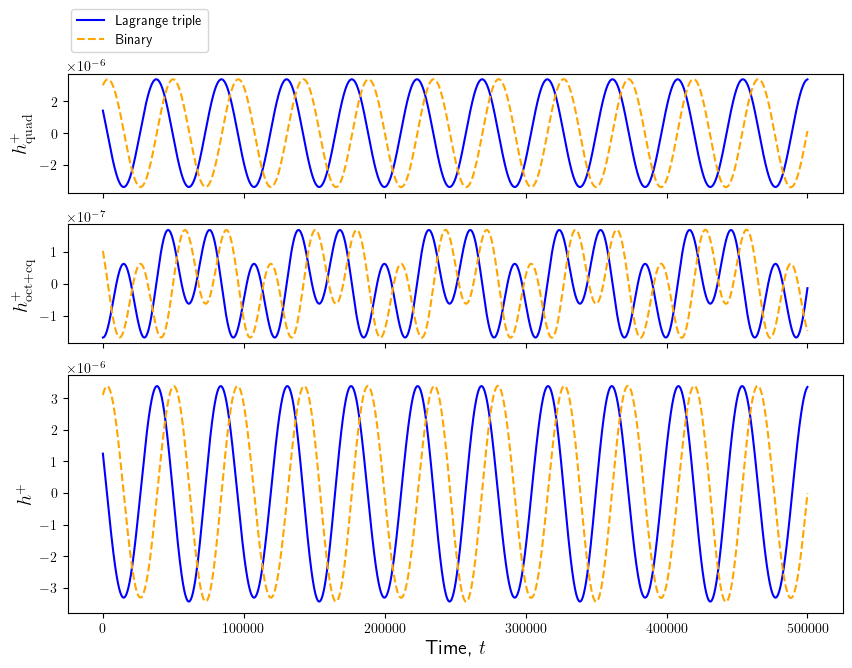

l = 937.407918522697, m1 = 0.5319248358502654, m2 = 0.5319248358502654, m3 = 2.7356134415156506, r = 1213.1782784828563, i = 36.86246313958458


In [52]:
params_2B_2 = [2000, 23.3, 13.6, 1e5, 75]
t = np.linspace(0, 500000, 1000000)

findOctDegeneracy(t, params_2B_2, 0.14, radRxn = True)

Min beta_1 for true degeneracy = 0.16645633291266582
Max beta_1 for true degeneracy = 0.20813441626883253


/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_3114/2151087883.py:5: RuntimeWarning: invalid value encountered in divide
  return np.sqrt(num/denom)
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_3114/2151087883.py:8: RuntimeWarning: invalid value encountered in sqrt
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))
/var/folders/9h/vxsw1hqs1md4rlkg5hqdrn_40000gn/T/ipykernel_3114/2151087883.py:8: RuntimeWarning: invalid value encountered in arcsin
  return np.degrees(np.arcsin(np.sqrt( 2 + 1/((1/4) - (9/2)*ratio_w_3w/F(b1, b2)))))


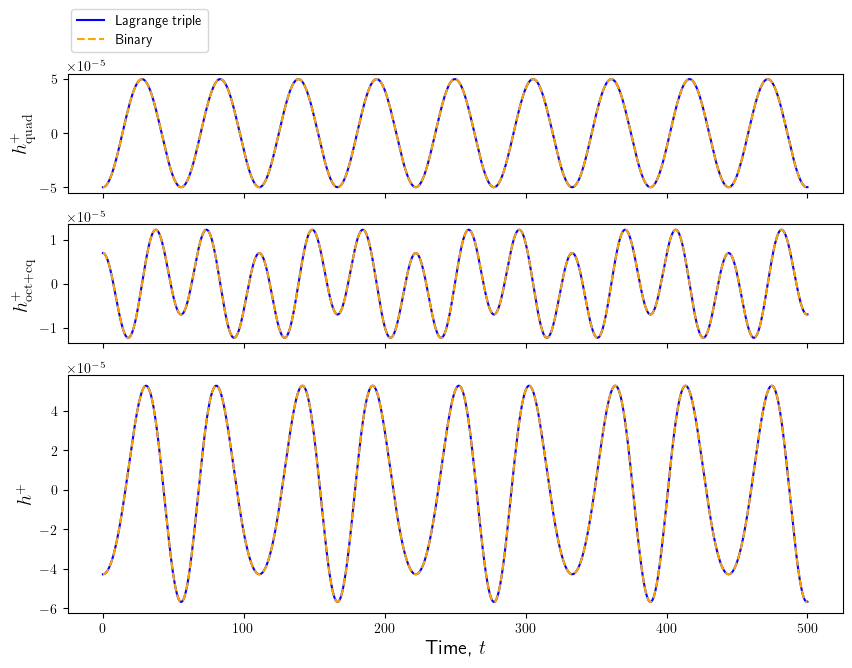

l = 20.51076216509582, m1 = 4.615680663153943, m2 = 4.615680663153943, m3 = 18.407445039883385, r = 246810.64437976872, i = 8.024654070464837


In [53]:
params_2B_3 = [40, 200, 5, 2e6, 5]
t = np.linspace(0, 500, 100000)

findOctDegeneracy(t, params_2B_3, 0.167, radRxn = False)

### Spectrogram

In [ ]:
t1 = np.linspace(0, 1900000, 100000)

f, t, Sxx = signal.spectrogram(h_quadPlus3B(*params_3B_1[0], t1, True) + h_octcqPlus3B(*params_3B_1[0], t1, True), fs = 10)
plt.pcolormesh(t, f, Sxx, shading = "gouraud")
plt.xlabel("Time, $t$", fontsize = "x-large")
plt.ylabel("Frequency, $\pi f_{\mathrm{GW}}$", fontsize = "x-large")

plt.show()